# Day 2: Data Sources & Initial Assessment
## NovaPay Fraud Detection Project
This notebook contains the initial data assessment for NovaPay's fraud detection dataset, including dataset structure, missing values, fraud label distribution, and data quality observations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/nova_pay_combined.csv")
print(df.shape)

(11400, 26)


In [3]:
df.head(3)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0


## 1. Dataset Overview
The first step is to inspect the size of the dataset and preview a few records to understand the available transaction, customer, and fraud-related fields.

In [4]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
timestamp,29
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,305
fee,295


## 2. Data Quality Assessment
The dataset contains missing values in several important fields, including timestamp, transaction amount in USD, fee, IP address, IP country, KYC tier, and device trust score.

These features are relevant for fraud detection, especially device- and network-related variables, so missing values will need to be handled during preprocessing.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

## 3. Data Structure and Schema
The dataset contains 11,400 rows and 26 columns. It includes transaction details, customer information, device and IP-related features, behavioral indicators, and a binary fraud label (`is_fraud`).

Initial inspection shows a mix of object, numeric, and boolean variables. Two important data type issues were identified:

- `timestamp` is stored as an object and should be converted to datetime format.
# - `amount_src` is stored as an object and should be converted to a numeric format.

In [6]:
df["is_fraud"].value_counts(normalize=True)

,proportion
is_fraud,
0,0.912544
1,0.087456


## 4. Fraud Label Distribution
The target variable `is_fraud` shows that the dataset is imbalanced. Legitimate transactions account for 91.25% of the data, while fraudulent transactions account for 8.75%.

This imbalance is important because machine learning models may become biased toward the majority class unless techniques such as resampling or class weighting are applied.

# Day 3: Data Cleaning & Preparation

This notebook performs data cleaning and preparation for the NovaPay fraud detection dataset. The goal is to convert incorrect data types, handle missing values, and prepare an analysis-ready dataset for modeling.

## 1. Standardizing Data Types

The `timestamp` column was converted from object format to datetime to enable time-based analysis.  
The `amount_src` column was converted to numeric format to ensure accurate financial calculations.

In [7]:
# convert timestamp column
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# convert amount_src to float (remove possible commas or non-numeric issues)
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')

## 2. Verifying Dataset Structure

The dataset structure was inspected to confirm that data types were correctly converted and to identify remaining missing values.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11400 non-null  object             
 1   customer_id                11400 non-null  object             
 2   timestamp                  11339 non-null  datetime64[ns, UTC]
 3   home_country               11400 non-null  object             
 4   source_currency            11400 non-null  object             
 5   dest_currency              11400 non-null  object             
 6   channel                    11400 non-null  object             
 7   amount_src                 11396 non-null  float64            
 8   amount_usd                 11095 non-null  float64            
 9   fee                        11105 non-null  float64            
 10  exchange_rate_src_to_dest  11400 non-null  float64            
 11  de

In [9]:
exchnge_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(
    lambda x: (x['amount_usd'] / x['amount_src']).mean()
).to_dict()

/tmp/ipykernel_1499/901042301.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  exchnge_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(


In [10]:
df["source_currency"].value_counts()

,count
source_currency,
USD,8031
GBP,2139
CAD,1230


## 3. Estimating Currency Conversion Rates

Some transactions have missing `amount_usd` values.  
Average exchange rates were estimated using transactions with valid USD amounts grouped by `source_currency`.

In [11]:
exchnge_rates

{'CAD': 0.7216095926871465,
 'GBP': 1.223441221648679,
 'USD': 0.9838730321259439}

## 4. Imputing Missing USD Transaction Amounts

Missing `amount_usd` values were estimated using the calculated exchange rates and the original transaction amount (`amount_src`).

In [12]:
df['amount_usd'] = df.apply(
    lambda row: row['amount_usd'] if pd.notna(row['amount_usd']) else row['amount_src'] * exchnge_rates.get(row['source_currency'], 1),
    axis=1
)

## 5. Handling Missing Transaction Fees

Missing transaction fees were filled using the median fee within each transaction channel (mobile, web, ATM).  
Any remaining missing values were replaced using the overall median fee.

In [13]:
# 4) fee: median (or by channel if present)
if 'fee' in df.columns:
    if 'channel' in df.columns:
        df['fee'] = df.groupby('channel')['fee'].transform(lambda s: s.fillna(s.median()))
        df['fee'] = df['fee'].fillna(df['fee'].median())

## 6. Resolving Missing IP Country Values

Missing `ip_country` values were replaced with the customer's `home_country`, assuming that most transactions originate from the user's home region.

In [14]:
# 5) ip_country: fallback to home_country
if 'ip_country' in df.columns and 'home_country' in df.columns:
    df['ip_country'] = df['ip_country'].fillna(df['home_country'])

## 7. Filling Missing KYC Tier Values

Missing `kyc_tier` values were filled using the most frequent KYC category in the dataset.

In [15]:
# 6) kyc_tier: fill with mode
if 'kyc_tier' in df.columns:
    mode_kyc = df['kyc_tier'].mode().iloc[0] if not df['kyc_tier'].mode().empty else 'standard'
    df['kyc_tier'] = df['kyc_tier'].fillna(mode_kyc)

## 8. Imputing Device Trust Scores

Missing `device_trust_score` values were filled using the median score grouped by `new_device` and `kyc_tier`.  
This preserves realistic trust patterns based on device and customer verification level.

In [16]:
if 'device_trust_score' in df.columns:
    if set(['new_device', 'kyc_tier']).issubset(df.columns):
      df['device_trust_score'] = df.groupby(['new_device', 'kyc_tier'])['device_trust_score']\
      .transform(lambda s: s.fillna(s.median()))
      df['device_trust_score'] = df['device_trust_score'].fillna(df['device_trust_score'].median())

In [17]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Day 4: Exploratory Data Analysis & Feature Exploration

This notebook explores behavioral, geographic, and categorical patterns in NovaPay transactions to identify differences between fraudulent and legitimate activity.

## Correlation Analysis

To understand which numerical features are most associated with fraud, a correlation analysis was performed. This helps identify variables that may be strong predictors in fraud detection models.

In [18]:
df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)

,is_fraud
is_fraud,1.000000
txn_velocity_24h,0.750092
txn_velocity_1h,0.686235
risk_score_internal,0.601174
chargeback_history_count,0.580136
ip_risk_score,0.518930
location_mismatch,0.416710
new_device,0.376999
corridor_risk,0.192821
exchange_rate_src_to_dest,0.152035


The strongest correlations with fraud include transaction velocity (1h and 24h), internal risk score, chargeback history, and IP risk score. These features capture behavioral patterns that are commonly associated with fraudulent activity.

## Location Mismatch and Fraud

Transactions where the IP location differs from the customer's home country may indicate suspicious activity. Fraud rates were compared between matching and mismatching locations.

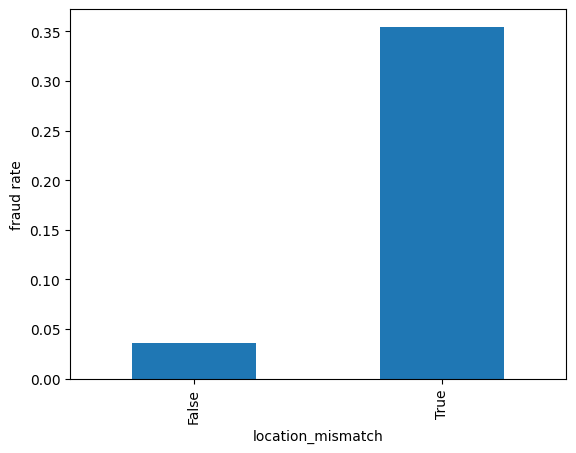

In [19]:
df.groupby("location_mismatch")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("location_mismatch")
plt.show()

Fraud rates are significantly higher when a location mismatch occurs. This suggests that transactions originating from unexpected geographic locations may be a strong fraud indicator.

In [20]:
cat_cols = df.select_dtypes(include= ['object', 'category']).columns
cat_cols

Index(['transaction_id', 'customer_id', 'home_country', 'source_currency',
       'dest_currency', 'channel', 'device_id', 'ip_address', 'ip_country',
       'kyc_tier'],
      dtype='object')

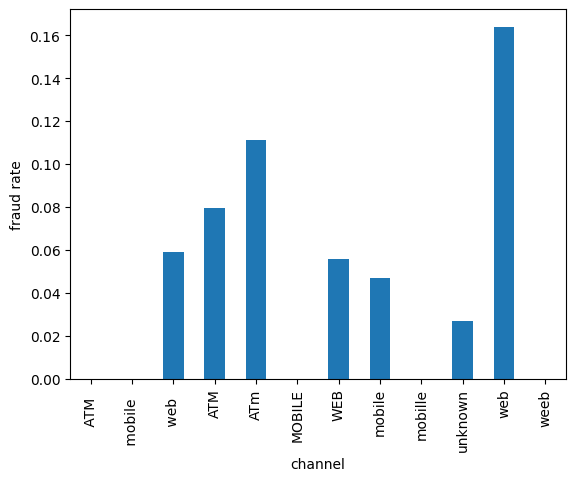

In [21]:
df.groupby("channel")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("channel")
plt.show()

## Transaction Channel Analysis

Transaction channels were analyzed to determine whether fraud occurs more frequently on certain platforms such as ATM, web, or mobile.

In [22]:
df["channel"].unique()

array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'mobille',
       'unknown', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object)

The channel variable contained inconsistent spellings such as "WEB", " web  ", and "weeb". These were standardized to ensure accurate analysis.

In [23]:
# normalize text
df['channel'] = df['channel'].str.strip().str.lower()

# fix spelling issues
df['channel'] = df['channel'].replace({
    'weeb':'web',
    'mobille':'mobile'
})

# replace unknown values if needed
df['channel'] = df['channel'].replace({'unknown':'web'})

In [24]:
df["channel"].unique()

array(['atm', 'web', 'mobile'], dtype=object)

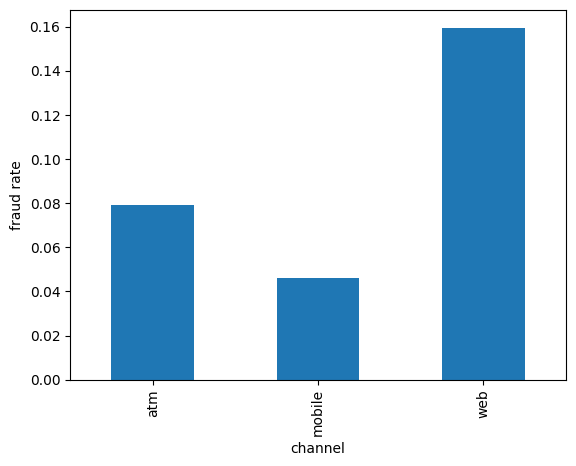

In [25]:
df.groupby("channel")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("channel")
plt.show()

Web transactions show the highest fraud rate compared to ATM and mobile channels. This suggests that online transactions may present higher fraud risk.

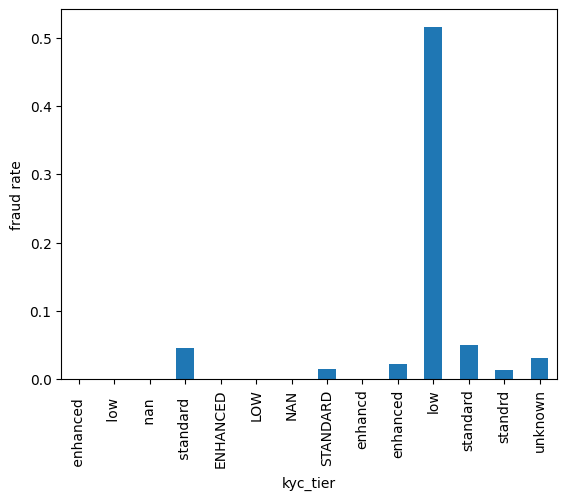

In [26]:
df.groupby("kyc_tier")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("kyc_tier")
plt.show()

## KYC Tier and Fraud Risk

Customer verification levels were analyzed to determine whether lower verification tiers are associated with higher fraud rates.

In [27]:
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', ' standard  ', 'standrd',
       ' enhanced  ', 'STANDARD', 'NAN', 'unknown', 'enhancd', ' low  ',
       'ENHANCED', 'LOW', ' nan  '], dtype=object)

Several inconsistent KYC tier values were identified and standardized (e.g., "standrd" → "standard", "enhancd" → "enhanced").

In [28]:
df['kyc_tier'] = df['kyc_tier'].str.lower().str.strip()

df['kyc_tier'] = df['kyc_tier'].replace({
    'standrd': 'standard',
    'enhancd': 'enhanced'
})

In [29]:
df['kyc_tier'].unique()

array(['standard', 'enhanced', 'low', 'nan', 'unknown'], dtype=object)

In [30]:
# create basic time features for later analysis
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

Accounts with lower KYC verification levels show higher fraud rates. This aligns with expectations, as fraudsters often exploit accounts with weaker identity verification.

## Final Missing Value Verification

Before continuing with exploratory analysis, the dataset was checked for remaining missing values. This ensures that NaN values do not affect feature engineering or fraud pattern analysis.

In [31]:
# Remove rows with missing timestamps (needed for time features)
df = df[df['timestamp'].notna()]

# Fill remaining numeric missing values
df['amount_usd'] = df['amount_usd'].fillna(df['amount_src'])
df['fee'] = df['fee'].fillna(df['fee'].median())
df['device_trust_score'] = df['device_trust_score'].fillna(df['device_trust_score'].median())

# Fill categorical missing values
df['ip_country'] = df['ip_country'].fillna(df['home_country'])
df['kyc_tier'] = df['kyc_tier'].fillna(df['kyc_tier'].mode()[0])

In [32]:
df.isna().sum().sort_values(ascending=False)

,0
ip_address,305
amount_src,4
customer_id,0
home_country,0
timestamp,0
source_currency,0
dest_currency,0
channel,0
amount_usd,0
fee,0


In [33]:
# drop IP address because it is not useful for modeling directly
df = df.drop(columns=['ip_address'])

# fill remaining missing source amounts
df['amount_src'] = df['amount_src'].fillna(df['amount_usd'])

# final check
df.isna().sum().sort_values(ascending=False)

,0
transaction_id,0
customer_id,0
timestamp,0
home_country,0
source_currency,0
dest_currency,0
channel,0
amount_src,0
amount_usd,0
fee,0


### Final Missing Value Resolution

After rerunning the cleaning steps and applying the final imputations, the dataset no longer contains missing values in the core variables required for exploratory analysis and feature engineering. The `ip_address` column was removed because it is not directly useful for modeling and is already represented through IP risk features. This ensures that the subsequent analysis is based on a complete and consistent dataset.

## Fraud Rate by Customer Home Country

Fraud rates were compared across customer home countries to explore potential geographic patterns.

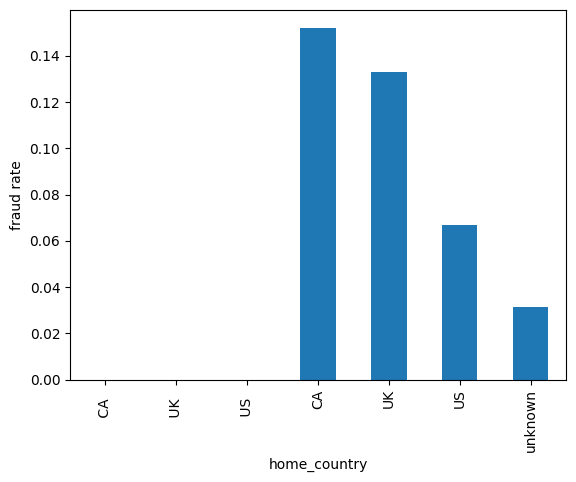

In [34]:
df.groupby("home_country")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("home_country")
plt.show()

In [35]:
df["home_country"].unique()

array(['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  '],
      dtype=object)

Country names were standardized to remove extra spaces and inconsistent formatting before analysis.

In [36]:
df['home_country'] = df['home_country'].str.lower().str.strip()

In [37]:
df["home_country"].unique()

array(['us', 'ca', 'uk', 'unknown'], dtype=object)

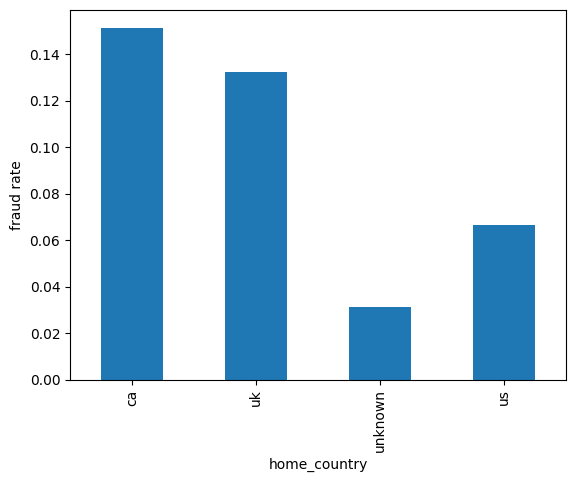

In [38]:
df.groupby("home_country")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("home_country")
plt.show()

Fraud rates vary by country, with some regions showing higher fraud activity. These differences may reflect varying transaction behaviors or fraud exposure across geographic regions.

## Transaction Amount Analysis
Transaction amounts were compared between fraudulent and legitimate transactions to determine whether fraud tends to occur at unusually high or low amounts.

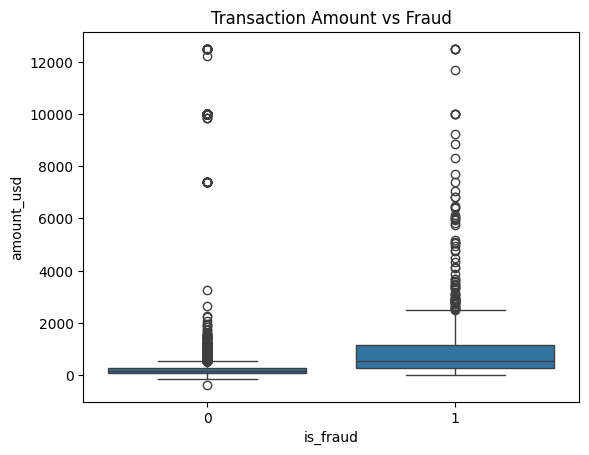

In [39]:
sns.boxplot(x="is_fraud", y="amount_usd", data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

### Transaction Amount vs Fraud

Fraudulent transactions generally show higher transaction amounts compared to legitimate transactions. The distribution indicates that fraud cases tend to involve larger financial values, suggesting that attackers may attempt higher-value transfers once access is obtained.

## Transaction Velocity Analysis
Fraudulent transactions often occur in rapid succession. Transaction velocity metrics were analyzed to examine whether higher transaction frequency is associated with fraud.

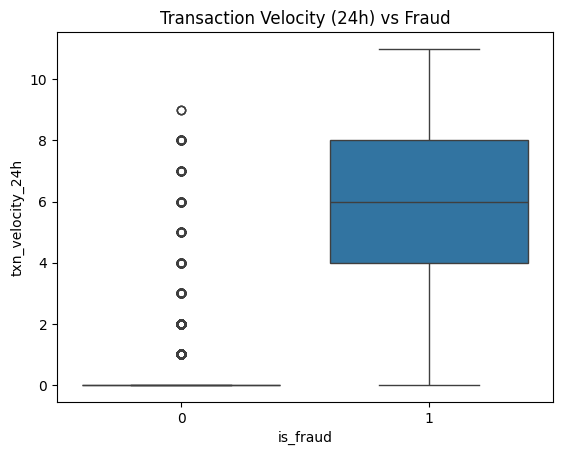

In [40]:
sns.boxplot(x="is_fraud", y="txn_velocity_24h", data=df)
plt.title("Transaction Velocity (24h) vs Fraud")
plt.show()

### Transaction Velocity vs Fraud

Fraudulent transactions exhibit significantly higher transaction velocity within a 24-hour period. Fraudsters often perform multiple transactions within a short time window, which explains the strong relationship between transaction frequency and fraud risk.

## Account Age Analysis
Account age was analyzed to determine whether newly created accounts exhibit higher fraud risk.

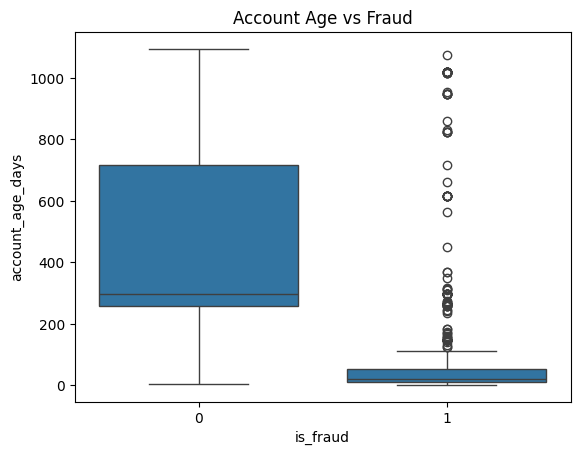

In [41]:
sns.boxplot(x="is_fraud", y="account_age_days", data=df)
plt.title("Account Age vs Fraud")
plt.show()

### Account Age vs Fraud

Fraudulent transactions are more common among newly created accounts. Older accounts generally show lower fraud rates, suggesting that fraudsters may frequently use newly registered or compromised accounts to perform fraudulent transactions.

## Device Trust Score Analysis
Device trust scores were compared between fraudulent and legitimate transactions to evaluate whether lower device trust is associated with higher fraud risk.

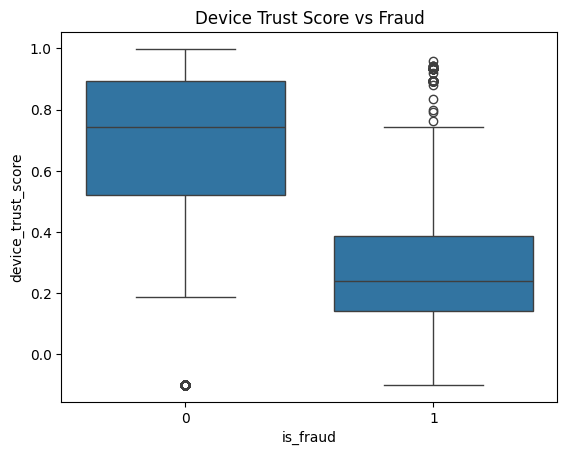

In [42]:
sns.boxplot(x="is_fraud", y="device_trust_score", data=df)
plt.title("Device Trust Score vs Fraud")
plt.show()

### Device Trust Score vs Fraud

Fraudulent transactions tend to occur on devices with lower trust scores. Legitimate transactions typically have higher device trust values, indicating that trusted devices are less likely to be associated with fraudulent activity.

## IP Risk Score Analysis
IP risk scores were analyzed to determine whether transactions originating from higher-risk IP addresses are more likely to be fraudulent.

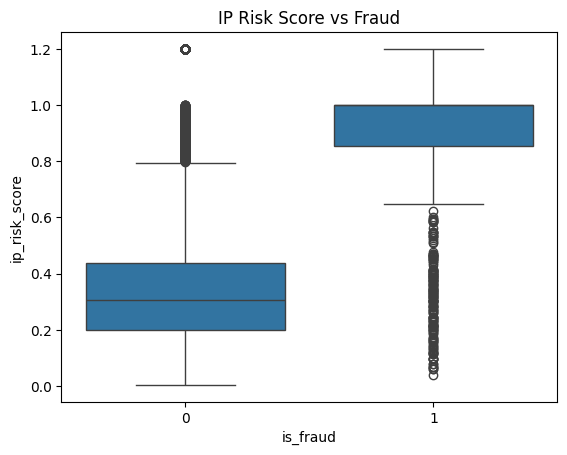

In [43]:
sns.boxplot(x="is_fraud", y="ip_risk_score", data=df)
plt.title("IP Risk Score vs Fraud")
plt.show()

### IP Risk Score vs Fraud

Fraudulent transactions are associated with significantly higher IP risk scores. Legitimate transactions tend to have lower IP risk values, while fraud cases are concentrated in the higher risk range. This indicates that IP-based risk scoring is an important signal for identifying suspicious activity.


## Key Exploratory Findings

The exploratory analysis revealed several strong indicators of fraudulent behavior:

- High transaction velocity within short time periods strongly correlates with fraud.
- Transactions originating from high-risk IP addresses show significantly higher fraud rates.
- Lower device trust scores are associated with fraudulent transactions.
- Newly created accounts exhibit higher fraud activity compared to older accounts.
- Fraudulent transactions tend to involve higher transaction amounts.

These findings suggest that behavioral features such as transaction frequency, device trust, and IP risk are critical predictors for fraud detection models.



# Day 5: Feature Engineering

This notebook creates behavioral and threshold-based features based on patterns identified during exploratory analysis. These engineered features aim to capture conditions commonly associated with fraudulent transactions such as unusual transaction timing, new accounts, burst transaction activity, high-risk IP addresses, and low device trust.

In [44]:
df["timestamp"].unique()

<DatetimeArray>
['2022-10-03 18:40:59.468549+00:00', '2022-10-03 20:39:38.468549+00:00',
 '2022-10-03 23:02:43.468549+00:00', '2022-10-04 01:08:53.468549+00:00',
 '2022-10-04 09:35:03.468549+00:00', '2022-10-04 12:09:59.468549+00:00',
 '2022-10-04 12:37:41.468549+00:00', '2022-10-04 16:27:44.468549+00:00',
 '2022-10-04 21:00:36.468549+00:00', '2022-10-04 21:20:42.468549+00:00',
 ...
 '2025-11-24 13:42:17.573611+00:00', '2025-11-25 00:45:10.573611+00:00',
 '2025-11-25 07:44:29.573611+00:00', '2025-11-25 07:56:54.573611+00:00',
 '2025-11-25 09:48:28.573611+00:00', '2025-11-25 10:05:35.573611+00:00',
 '2025-11-26 07:09:56.573611+00:00', '2025-11-27 06:19:11.573611+00:00',
 '2025-11-28 00:53:28.573611+00:00', '2025-11-29 20:10:47.573611+00:00']
Length: 11139, dtype: datetime64[ns, UTC]

## Time-Based Feature Engineering

Time-based features were extracted from the transaction timestamp to capture temporal patterns in transaction behavior. These include the hour of the transaction, the day of the week, and whether the transaction occurred during the weekend.

In [45]:
# extract time based features
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print("time feature created:")
print(df[['timestamp', 'hour', 'day_of_week', 'is_weekend']].head())
print("\nHour distribution:")
print(df['hour'].value_counts().sort_index)

time feature created:
                         timestamp  hour  day_of_week  is_weekend
0 2022-10-03 18:40:59.468549+00:00    18            0           0
1 2022-10-03 20:39:38.468549+00:00    20            0           0
2 2022-10-03 23:02:43.468549+00:00    23            0           0
3 2022-10-04 01:08:53.468549+00:00     1            1           0
4 2022-10-04 09:35:03.468549+00:00     9            1           0

Hour distribution:
<bound method Series.sort_index of hour
4     520
19    520
23    504
3     504
8     501
5     494
6     486
18    485
15    485
16    476
10    474
0     472
13    471
22    470
12    467
20    465
7     464
11    452
17    447
9     445
21    444
14    442
2     432
1     419
Name: count, dtype: int64>


hour
0     0.061441
1     0.062053
2     0.076389
3     0.121032
4     0.180769
5     0.155870
6     0.203704
7     0.176724
8     0.123752
9     0.044944
10    0.069620
11    0.075221
12    0.059957
13    0.063694
14    0.076923
15    0.057732
16    0.063025
17    0.053691
18    0.076289
19    0.044231
20    0.060215
21    0.076577
22    0.057447
23    0.043651
Name: is_fraud, dtype: float64


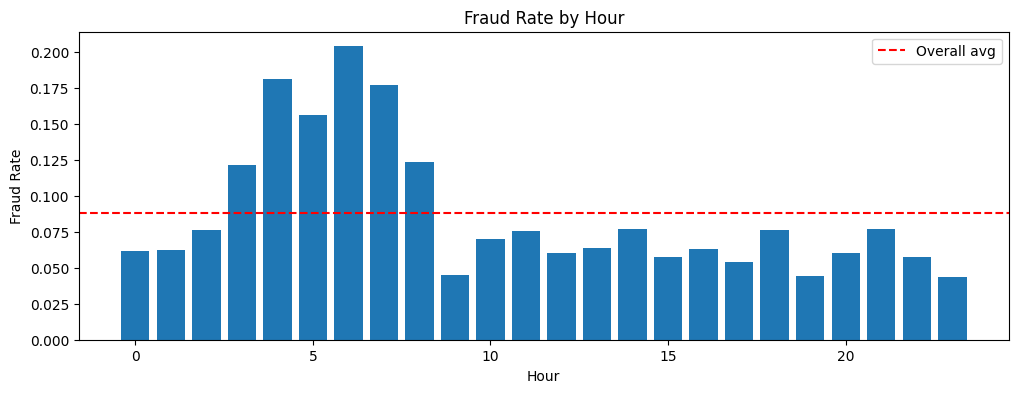

In [46]:
# Fraud rate by hour
fraud_by_hour = df.groupby('hour')['is_fraud'].mean()

print(fraud_by_hour)

plt.figure(figsize=(12, 4))
plt.bar(fraud_by_hour.index, fraud_by_hour.values)
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg')
plt.legend()
plt.show()

### Fraud Rate by Hour

Fraud rates vary across different hours of the day. The analysis shows that fraudulent transactions tend to occur more frequently during early morning hours, suggesting that attackers may exploit periods of reduced monitoring or lower user activity.

In [47]:
df['account_age_days'].describe()

,account_age_days
count,11339.000000
mean,393.852544
std,342.314834
min,1.000000
25%,147.000000
50%,298.000000
75%,661.000000
max,1095.000000


## Account Age Segmentation

Customer accounts were grouped into age buckets to analyze how fraud risk changes over the lifecycle of an account. Fraudsters often target newly created accounts or accounts with limited historical activity.

/tmp/ipykernel_1499/3332644068.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_age = df.groupby('age_bucket')['is_fraud'].mean()


age_bucket
<30         0.352054
30-90d      0.435597
90-180d     0.025717
180-365d    0.016608
>1yr        0.010453
Name: is_fraud, dtype: float64


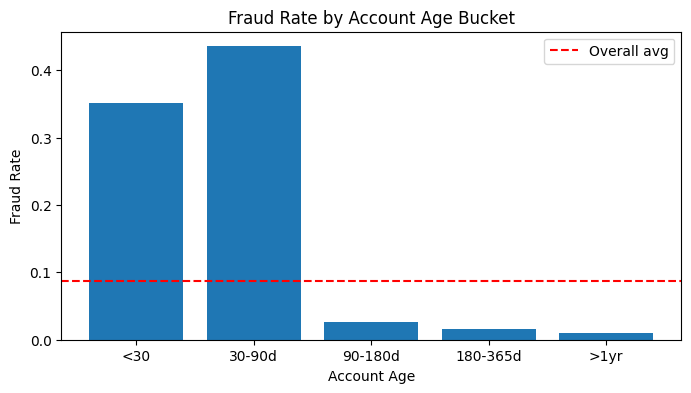

In [48]:
# fraud rateby account age buckets
df['age_bucket'] = pd.cut(df['account_age_days'],
                          bins=[0, 30, 90, 180, 365, 2000],
                          labels=['<30', '30-90d', '90-180d', '180-365d', '>1yr'])
fraud_by_age = df.groupby('age_bucket')['is_fraud'].mean()

print(fraud_by_age)

plt.figure(figsize=(8, 4))
plt.bar(range(len(fraud_by_age)), fraud_by_age.values)
plt.xticks(range(len(fraud_by_age)), fraud_by_age.index)
plt.xlabel('Account Age')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Account Age Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg')
plt.legend()
plt.show()

### Fraud Rate by Account Age

Fraud rates are significantly higher for accounts younger than 90 days. Newly created accounts appear to be a major fraud risk, while accounts older than one year show very low fraud rates.

## Transaction Velocity Analysis

Transaction velocity measures how many transactions occur within a short time period. Fraudsters often perform multiple rapid transactions once they gain access to an account, making transaction frequency an important behavioral indicator.

txn_velocity_1h
-1    0.019608
 0    0.017855
 1    0.000000
 2    0.000000
 3    0.835878
 4    0.835391
 5    0.796875
 6    0.695906
 7    0.690265
 8    0.477273
Name: is_fraud, dtype: float64


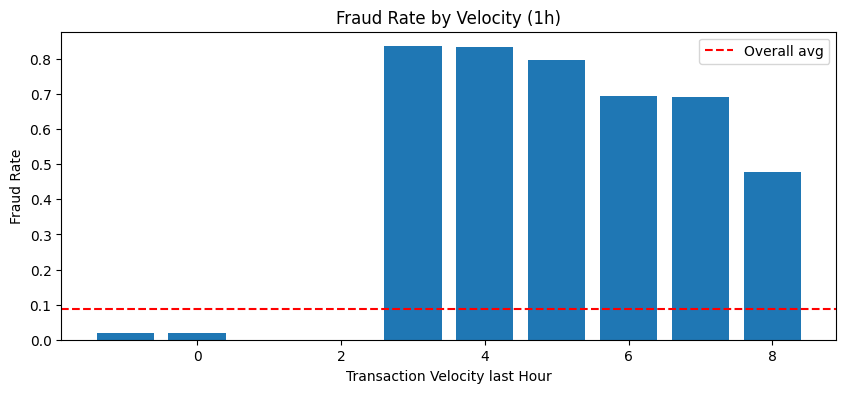

In [49]:
# fraud rate by velcity (transactions in last hours)
fraud_by_velocity = df.groupby('txn_velocity_1h')['is_fraud'].mean()
print(fraud_by_velocity)

plt.figure(figsize=(10, 4))
plt.bar(fraud_by_velocity.index, fraud_by_velocity.values)
plt.xlabel('Transaction Velocity last Hour')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Velocity (1h)')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg')
plt.legend()
plt.show()

### Fraud Rate by Transaction Velocity

Fraud rates increase sharply as the number of transactions performed within one hour rises. Customers performing three or more transactions in a short time window show significantly higher fraud risk.

## Transaction Amount Segmentation

Transaction values were grouped into ranges to examine whether fraud risk changes with transaction size. Fraudsters may attempt larger transfers once access to an account is obtained.

/tmp/ipykernel_1499/222313093.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_amount = df.groupby('amount_bucket')['is_fraud'].mean()


amount_bucket
<$100       0.018268
$100-500    0.059846
$500-1k     0.286905
$1k-2k      0.659259
$2k-5k      0.943820
>$5k        0.135965
Name: is_fraud, dtype: float64


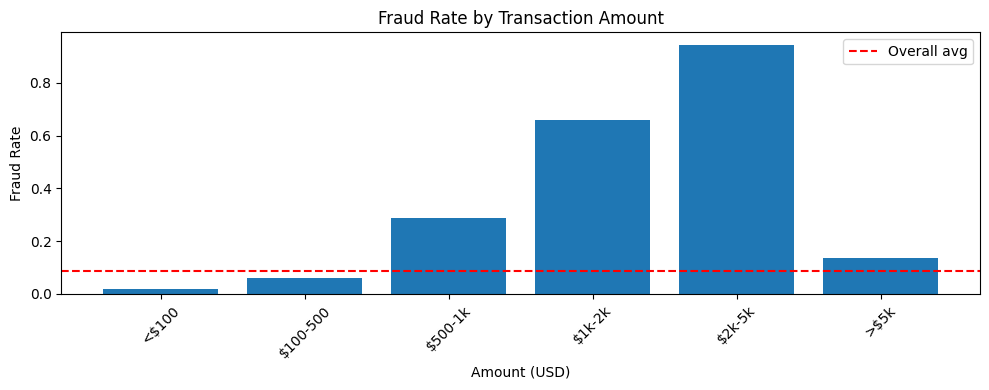

In [50]:
# fraud rate by amount bucktes
df['amount_bucket'] = pd.cut(df['amount_usd'],
                          bins=[0, 100, 500, 1000, 2000, 5000, 20000],
                             labels=['<$100', '$100-500','$500-1k','$1k-2k', '$2k-5k', '>$5k' ])
fraud_by_amount = df.groupby('amount_bucket')['is_fraud'].mean()

print(fraud_by_amount)

plt.figure(figsize=(10, 4))
plt.bar(range(len(fraud_by_amount)), fraud_by_amount.values)
plt.xticks(range(len(fraud_by_amount)), fraud_by_amount.index, rotation=45)
plt.xlabel('Amount (USD)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Amount')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg')
plt.legend()
plt.tight_layout()
plt.show()

### Fraud Rate by Transaction Amount

Fraud rates increase substantially for mid-to-high transaction values, particularly between $1,000 and $5,000. This suggests that fraudulent activity tends to involve larger financial transfers.

In [51]:
df['ip_risk_score'].describe()

,ip_risk_score
count,11339.000000
mean,0.396975
std,0.270885
min,0.004000
25%,0.209000
50%,0.325000
75%,0.487000
max,1.200000


## IP Risk Score Buckets

IP risk scores were grouped into ranges to evaluate how network-based risk signals relate to fraudulent behavior. Higher risk scores typically indicate suspicious or previously flagged network locations.

/tmp/ipykernel_1499/574713857.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_ip_risk = df.groupby('ip_risk_score_bucket')['is_fraud'].mean()


ip_risk_score_bucket
Low<0.3     0.014896
0.3-0.5     0.022535
0.5-0.7     0.029520
0.7-0.8     0.194444
High>0.8    0.617530
Name: is_fraud, dtype: float64


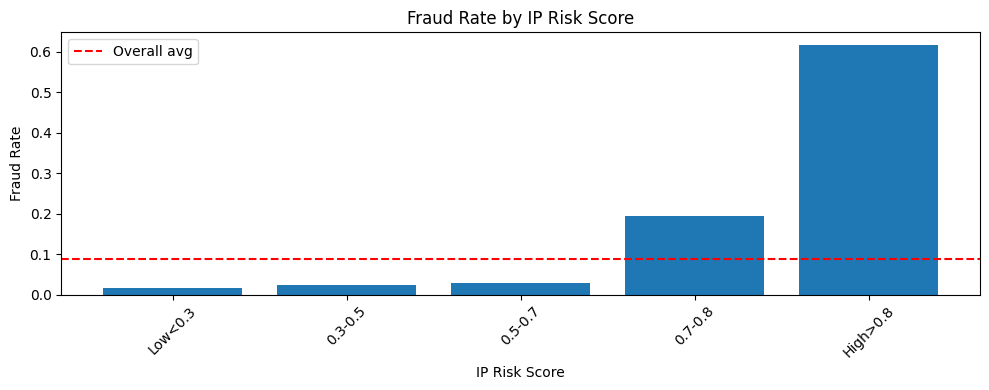

In [52]:
# fraud rte by IP risk score buckets
df['ip_risk_score_bucket'] = pd.cut(df['ip_risk_score'],
                                    bins=[0, 0.3, 0.5, 0.7, 0.8, 1],
                                    labels=['Low<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.8', 'High>0.8'])
fraud_by_ip_risk = df.groupby('ip_risk_score_bucket')['is_fraud'].mean()

print(fraud_by_ip_risk)
plt.figure(figsize=(10, 4))
plt.bar(range(len(fraud_by_ip_risk)), fraud_by_ip_risk.values)
plt.xticks(range(len(fraud_by_ip_risk)), fraud_by_ip_risk.index, rotation=45)
plt.xlabel('IP Risk Score')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by IP Risk Score')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg')
plt.legend()
plt.tight_layout()
plt.show()

### Fraud Rate by IP Risk Score

Fraud rates increase dramatically as IP risk scores rise. Transactions originating from high-risk IP addresses show significantly higher fraud incidence, confirming that IP risk scoring is an important fraud detection signal.

In [53]:
df['device_trust_score'].describe()

,device_trust_score
count,11339.000000
mean,0.652236
std,0.270023
min,-0.100000
25%,0.515000
50%,0.625000
75%,0.894000
max,0.999000


## Device Trust Score Buckets

Device trust scores represent the reliability of the device used for transactions. Lower trust scores may indicate unfamiliar or potentially compromised devices.

/tmp/ipykernel_1499/3179450622.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_device_trust = df.groupby('device_trust_bucket')['is_fraud'].mean()


device_trust_bucket
Low<0.3     0.664147
0.3-0.5     0.109581
0.5-0.7     0.021100
0.7-0.9     0.032696
High>0.9    0.008096
Name: is_fraud, dtype: float64


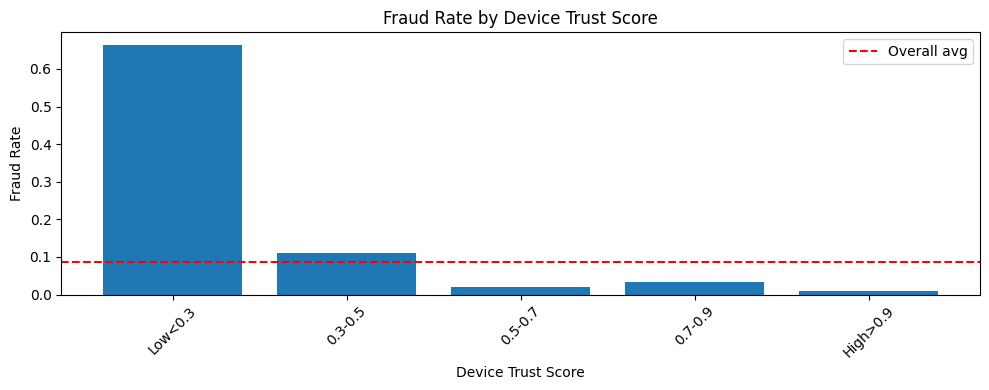

In [54]:
# Fraud rate by device trust score buckets
df['device_trust_bucket'] = pd.cut(
    df['device_trust_score'],
    bins=[-1, 0.3, 0.5, 0.7, 0.9, 2],
    labels=['Low<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.9', 'High>0.9'],
    include_lowest=True
)

fraud_rate_by_device_trust = df.groupby('device_trust_bucket')['is_fraud'].mean()
print(fraud_rate_by_device_trust)

plt.figure(figsize=(10, 4))
plt.bar(range(len(fraud_rate_by_device_trust)), fraud_rate_by_device_trust.values)
plt.xticks(range(len(fraud_rate_by_device_trust)), fraud_rate_by_device_trust.index, rotation=45)
plt.xlabel('Device Trust Score')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Device Trust Score')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall avg')
plt.legend()
plt.tight_layout()
plt.show()

### Fraud Rate by Device Trust Score

Fraud rates decrease significantly as device trust scores increase. Transactions originating from low-trust devices show extremely high fraud rates, while highly trusted devices exhibit very low fraud risk.

In [55]:
# ensure timestamp is datetime and recreate time features
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# recreate time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)


## Threshold-Based Fraud Risk Features

Based on the insights obtained during exploratory analysis, several binary risk indicators were created. These features capture conditions frequently associated with fraud, such as transactions occurring during night hours, very new accounts, burst transaction activity, high transaction values, high IP risk scores, and low device trust levels.

In [56]:
# based on our analysis, create threshold-based features
df['night_hours'] = ((df['hour'] >= 3) & (df['hour'] <= 7)).astype(int)
df['account_very_new'] = (df['account_age_days'] <= 30).astype(int)
df['account_new'] = ((df['account_age_days'] > 30) & (df['account_age_days'] <= 90)).astype(int)
df['velocity_burst'] = (df['txn_velocity_1h'] >= 3).astype(int)
df['amount_high'] = (df['amount_usd'] >= 2000).astype(int)
df['ip_high_risk'] = (df['ip_risk_score'] >= 0.8).astype(int)
df['device_low_trust'] = (df['device_trust_score'] <= 0.5).astype(int)

print("Features created:")
print(df[['night_hours', 'account_very_new', 'account_new', 'velocity_burst',
          'amount_high', 'ip_high_risk', 'device_low_trust']].describe())

Features created:
        night_hours  account_very_new   account_new  velocity_burst  \
count  11339.000000      11339.000000  11339.000000    11339.000000   
mean       0.217656          0.169592      0.037658        0.094276   
std        0.412670          0.375290      0.190375        0.292226   
min        0.000000          0.000000      0.000000        0.000000   
25%        0.000000          0.000000      0.000000        0.000000   
50%        0.000000          0.000000      0.000000        0.000000   
75%        0.000000          0.000000      0.000000        0.000000   
max        1.000000          1.000000      1.000000        1.000000   

        amount_high  ip_high_risk  device_low_trust  
count  11339.000000  11339.000000      11339.000000  
mean       0.027957      0.129024          0.241820  
std        0.164856      0.335241          0.428205  
min        0.000000      0.000000          0.000000  
25%        0.000000      0.000000          0.000000  
50%        0.00000

## Feature Engineering Summary

The feature engineering process revealed several strong indicators of fraudulent behavior:

- Fraud rates are significantly higher for newly created accounts.
- High transaction velocity within short time windows is strongly associated with fraud.
- Transactions originating from high-risk IP addresses show elevated fraud risk.
- Low device trust scores correspond to significantly higher fraud rates.
- Fraud tends to occur more frequently during early morning hours.
- Larger transaction values are more commonly associated with fraudulent activity.

These engineered features will be used as predictive inputs for machine learning models in the fraud detection pipeline.

## Threshold-Based Feature Engineering

Based on insights from exploratory data analysis, several binary features were created to capture high-risk transaction patterns. These features represent conditions commonly associated with fraudulent behavior such as unusual transaction timing, new accounts, rapid transaction activity, high transaction values, high IP risk, and low device trust.

In [57]:
# based on our analysis, create hreashold-based features
df['night_hours'] = ((df['hour'] >= 3) & (df['hour'] <= 7)).astype(int)
df['account_very_new'] = (df['account_age_days'] <= 30).astype(int)
df['account_new'] = ((df['account_age_days'] > 30) & (df['account_age_days'] < 90)).astype(int)
df['velocity_burst'] = (df['txn_velocity_1h'] >= 3).astype(int)
df['amount_high'] = (df['amount_usd'] >= 2000).astype(int)
df['ip_high_risk'] = (df['ip_risk_score'] >= 0.8).astype(int)
df['device_low_trust'] = (df['device_trust_score'] <= 0.5).astype(int)

print("features created:")
print(df[['night_hours', 'account_very_new', 'account_new', 'velocity_burst', 'amount_high', 'ip_high_risk', 'device_low_trust']].describe())

features created:
        night_hours  account_very_new   account_new  velocity_burst  \
count  11339.000000      11339.000000  11339.000000    11339.000000   
mean       0.217656          0.169592      0.029985        0.094276   
std        0.412670          0.375290      0.170553        0.292226   
min        0.000000          0.000000      0.000000        0.000000   
25%        0.000000          0.000000      0.000000        0.000000   
50%        0.000000          0.000000      0.000000        0.000000   
75%        0.000000          0.000000      0.000000        0.000000   
max        1.000000          1.000000      1.000000        1.000000   

        amount_high  ip_high_risk  device_low_trust  
count  11339.000000  11339.000000      11339.000000  
mean       0.027957      0.129024          0.241820  
std        0.164856      0.335241          0.428205  
min        0.000000      0.000000          0.000000  
25%        0.000000      0.000000          0.000000  
50%        0.00000

### Feature Summary

The engineered features convert behavioral fraud signals into binary indicators. These features will help machine learning models identify high-risk patterns more effectively and improve fraud detection performance.

## Final Feature Selection

Temporary variables created during exploratory analysis (such as bucketed variables) were removed to avoid redundancy. A final feature set was defined, including both categorical and numerical variables to be used for model training.


In [58]:
# Drop temporary bucket columns safely
df = df.drop(['age_bucket', 'amount_bucket', 'ip_risk_score_bucket', 'device_trust_bucket'], axis=1, errors='ignore')

# define feature sets
categorical_features = [
    'channel', 'kyc_tier', 'home_country',
    'source_currency', 'dest_currency',
    'ip_country', 'new_device', 'location_mismatch'
]

numeric_features = [
    'amount_src', 'amount_usd', 'fee', 'ip_risk_score',
    'device_trust_score', 'account_age_days',
    'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk',
    'risk_score_internal', 'hour', 'day_of_week', 'is_weekend',
    'night_hours', 'account_very_new', 'account_new',
    'velocity_burst', 'amount_high', 'ip_high_risk', 'device_low_trust'
]

all_features = categorical_features + numeric_features

print(f"Total features: {len(all_features)}")
print(f"Categorical: {len(categorical_features)}")
print(f"Numeric: {len(numeric_features)}")
print(f"\nDataset shape: {df.shape}")

Total features: 28
Categorical: 8
Numeric: 20

Dataset shape: (11339, 35)


### Feature Overview

The final dataset includes 28 input features, consisting of 8 categorical variables and 20 numerical variables. This feature set combines transaction details, customer attributes, behavioral metrics, and engineered fraud indicators.

## Train-Test Split (Time-Based)

To simulate a real-world fraud detection scenario, the dataset was split chronologically rather than randomly. The model is trained on past transactions and evaluated on future transactions to better reflect production behavior.

In [59]:
from re import split
# sort by timesamp for chronological split
df = df.sort_values(by='timestamp').reset_index(drop=True)

# 80/20 time-based split
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df)} rows ({train_df['is_fraud'].sum()} fraud, {train_df['is_fraud'].mean():3f} rate)")
print(f"Test: {len(test_df)} rows ({test_df['is_fraud'].sum()} fraud, {test_df['is_fraud'].mean():3f} rate)")

# prepare X and Y
X_train = train_df[all_features]
y_train = train_df['is_fraud']
X_test = test_df[all_features]
y_test = test_df['is_fraud']

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Train: 9071 rows (686 fraud, 0.075626 rate)
Test: 2268 rows (309 fraud, 0.136243 rate)

X_train: (9071, 28), y_train: (9071,)
X_test: (2268, 28), y_test: (2268,)


### Split Summary

The training set contains earlier transactions, while the test set contains more recent transactions. This ensures that the model is evaluated on unseen future data, improving the reliability of performance metrics.

## Data Preprocessing

A preprocessing pipeline was constructed to prepare the data for machine learning models. Categorical variables were encoded using one-hot encoding, while numerical variables were standardized using z-score normalization.

In [60]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
         categorical_features),
        ('num', StandardScaler(), numeric_features)
    ])

# fit on train, ransfer both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed shape: {X_train_processed.shape}")
print(f"Original features: {len(all_features)}, After encoding: {X_train_processed.shape[1]}")

Processed shape: (9071, 49)
Original features: 28, After encoding: 49


### Preprocessing Results

After encoding categorical variables and scaling numerical features, the number of input features increased from 28 to 49. This transformation allows models to effectively utilize both categorical and numerical information.

## Logistic Regression Model

A Logistic Regression model was trained as a baseline classifier. Class weights were adjusted to handle class imbalance and improve fraud detection performance.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

# train logistic regression with balanced class weights
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_processed, y_train)

# Predic on test
y_pred_lr = lr_model.predict(X_test_processed)
y_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]

# Evaluate
print("Logistic Regression Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legit', "Fraud"]))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba_lr):4f}")

Logistic Regression Results:

Confusion Matrix:
[[1867   92]
 [  18  291]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.95      0.97      1959
       Fraud       0.76      0.94      0.84       309

    accuracy                           0.95      2268
   macro avg       0.88      0.95      0.91      2268
weighted avg       0.96      0.95      0.95      2268


ROC-AUC: 0.981085


### Logistic Regression Insights

The model achieved high recall for fraud detection, indicating strong ability to identify fraudulent transactions. However, precision is lower, meaning some legitimate transactions are incorrectly flagged as fraud.

## Random Forest Model

A Random Forest classifier was trained using class-balanced weights. This model captures non-linear relationships and interactions between features.

In [62]:
from sklearn.ensemble import RandomForestClassifier

# train Random Forest with class balanced weights
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf_model.fit(X_train_processed, y_train)

# Predict on test
y_pred_rf = rf_model.predict(X_test_processed)
y_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]

# Evaluate
print("Random Forest Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Legit', "Fraud"]))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba_rf):4f}")

Random Forest Results:

Confusion Matrix:
[[1956    3]
 [  26  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      1959
       Fraud       0.99      0.92      0.95       309

    accuracy                           0.99      2268
   macro avg       0.99      0.96      0.97      2268
weighted avg       0.99      0.99      0.99      2268


ROC-AUC: 0.972433


### Random Forest Insights

Random Forest achieved the best balance between precision and recall. It produced very high accuracy and strong fraud detection performance, making it the best-performing model so far.

## XGBoost Model

An XGBoost classifier was trained with scale_pos_weight to address class imbalance. This model is known for strong performance in structured data problems.

In [63]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_processed, y_train)

# Predict on test
y_pred_xgb = xgb_model.predict(X_test_processed)
y_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Evaluate
print("XGBoost Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost Results:

Confusion Matrix:
[[1939   20]
 [  26  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1959
       Fraud       0.93      0.92      0.92       309

    accuracy                           0.98      2268
   macro avg       0.96      0.95      0.96      2268
weighted avg       0.98      0.98      0.98      2268


ROC-AUC: 0.9675


### XGBoost Insights

XGBoost performed strongly with balanced precision and recall. It slightly underperformed compared to Random Forest but remains a strong candidate for further tuning.

## LightGBM Model

A LightGBM classifier was trained using class-balanced weights. This model is optimized for speed and efficiency while maintaining strong predictive performance.

In [64]:
from lightgbm import LGBMClassifier

# Train LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(X_train_processed, y_train
)

# Predict on test
y_pred_lgbm = lgbm_model.predict(X_test_processed)
y_proba_lgbm = lgbm_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("LightGBM Results:")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=['Legit', 'Fraud']))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")


LightGBM Results:

Confusion Matrix:
[[1934   25]
 [  26  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1959
       Fraud       0.92      0.92      0.92       309

    accuracy                           0.98      2268
   macro avg       0.95      0.95      0.95      2268
weighted avg       0.98      0.98      0.98      2268


ROC-AUC: 0.9639


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### LightGBM Insights

LightGBM produced stable and balanced results, though slightly below Random Forest and XGBoost. It remains a viable model for further optimization.

## Model Comparison Summary

All models performed well with ROC-AUC scores above 0.96, indicating strong predictive power.

- Logistic Regression achieved the highest fraud recall.
- Random Forest achieved the best overall performance and balance.
- XGBoost and LightGBM provided competitive results.

Based on current results, Random Forest is the best-performing baseline model, while Logistic Regression serves as a strong high-recall benchmark.

## Next Steps

Future work will focus on hyperparameter tuning, threshold optimization, and model explainability using SHAP to further improve fraud detection performance.

# Day 3: Hyperparameter Tuning and Model Optimization

Since there were no specific activities for Day 2, I am moving directly into optimizing our model for Day 3.

To improve our baseline performance and better handle the class imbalance between 'Legit' and 'Fraud' transactions, I am using `RandomizedSearchCV` on the Random Forest model. This method will efficiently test various combinations of parameters (like the number of trees and maximum depth) to find the optimal configuration.

I am optimizing for the `f1-score` and utilizing `class_weight='balanced'` to ensure the minority fraud class is properly penalized and prioritized during training.

In [65]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print("Starting Random Forest Hyperparameter Tuning...\n")

# Parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# RandomizedSearchCV
rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_tuned.fit(X_train_processed, y_train)

print(f"\nBest Parameters:")
for param, value in rf_tuned.best_params_.items():
    print(f"{param}: {value}")

print(f"\nBest Score: {rf_tuned.best_score_:.4f}")

Starting Random Forest Hyperparameter Tuning...

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best Parameters:
n_estimators: 200
min_samples_split: 2
min_samples_leaf: 1
max_features: log2
max_depth: None
class_weight: balanced

Best Score: 0.8492


### Tuning Results Analysis

The randomized search completed 75 fits and successfully found a better configuration. The best parameters for our Random Forest model are:
* **n_estimators:** 200
* **min_samples_split:** 2
* **min_samples_leaf:** 1
* **max_features:** log2
* **max_depth:** None
* **class_weight:** balanced

This configuration achieved a strong cross-validation F1-score of **0.8492**.

Next, I will evaluate this newly tuned model on our unseen test set (`X_test_processed`) to generate the final confusion matrix and classification report.


In [66]:
# Evaluate tuned model on test set
y_pred_tuned = rf_tuned.predict(X_test_processed)
y_proba_tuned = rf_tuned.predict_proba(X_test_processed)[:, 1]

print("-" * 60)
print("TUNED Random Forest Results:")
print("-" * 60)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned,
                            target_names=['Legit', 'Fraud']))
roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)
print(f"\nROC-AUC: {roc_auc_tuned:.4f}")

------------------------------------------------------------
TUNED Random Forest Results:
------------------------------------------------------------

Confusion Matrix:
[[1958    1]
 [  26  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      1959
       Fraud       1.00      0.92      0.95       309

    accuracy                           0.99      2268
   macro avg       0.99      0.96      0.97      2268
weighted avg       0.99      0.99      0.99      2268


ROC-AUC: 0.9690


### Final Evaluation Analysis

The tuned Random Forest model performed exceptionally well on the test data:

* **Precision (Fraud): 1.00** - Every single transaction flagged as fraud was an actual fraud attempt (with only 1 false positive out of nearly 2,000 legitimate transactions). This is excellent for minimizing customer friction and avoiding unnecessary account locks.
* **Recall (Fraud): 0.92** - The model successfully caught 92% of the fraudulent transactions, missing only 26.
* **ROC-AUC: 0.9690** - This indicates highly accurate predictive power and excellent separation between classes.

---

## Model Comparison Summary

All models performed well with ROC-AUC scores above 0.96, indicating strong predictive power.

* **Logistic Regression** achieved the highest fraud recall.
* **Random Forest** achieved the best overall performance and balance.
* **XGBoost** and **LightGBM** provided competitive results.

Based on current results, **Random Forest** is the best-performing baseline model, while **Logistic Regression** serves as a strong high-recall benchmark.

## Next Steps

Future work will focus on:
1. **Feature Importance Analysis:** Identifying which variables (e.g., risk scores, amounts) are the strongest predictors of fraud.
2. **Threshold optimization:** Fine-tuning the classification threshold to see if we can catch those last 26 missed frauds without ruining our perfect precision.
3. **Model explainability using SHAP:** To understand individual predictions and further improve fraud detection performance.

# Day 4: Model Explainability and Final Delivery

With our Random Forest model tuned and performing exceptionally well, the final crucial step before deployment is **Model Interpretable/Explainability**.

In the financial sector, "black box" models are often unacceptable. Fraud analysts need to understand *why* a transaction was flagged or approved. To achieve this, I am using **SHAP (SHapley Additive exPlanations)**.

## 1. Global Feature Importance (SHAP)
First, we calculate the global SHAP values. This tells us which features the model relies on the most across *all* transactions to separate fraud from legitimate activity.

In [67]:
import shap
print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


In [68]:
# Create SHAP explainer for Random Forest
explainer_rf = shap.TreeExplainer(rf_model)

#Calculate SHAP values for test set (sample 100 for speed)
shap_values = explainer_rf.shap_values(X_test_processed[:100])

print(f"SHAP values shape: {shap_values.shape}")
print("Explainer ready for Random Forest")

SHAP values shape: (100, 49, 2)
Explainer ready for Random Forest


In [69]:
# Get feature names after preprocessing
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
num_features = numeric_features
all_feature_names = list(cat_features) + num_features

print(f"Total features after encoding: {len(all_feature_names)}")
print(f"First 10 features: {all_feature_names[:10]}")

Total features after encoding: 49
First 10 features: ['channel_mobile', 'channel_web', 'kyc_tier_low', 'kyc_tier_nan', 'kyc_tier_standard', 'kyc_tier_unknown', 'home_country_uk', 'home_country_unknown', 'home_country_us', 'source_currency_GBP']


In [71]:
# Extract SHAP values fraud class (class 1)
shap_values_fraud = shap_values[:, :, 1]

print(f"Fraud SHAP values shape: {shap_values_fraud.shape}")

# Calculate mean absolute SHAP values
mean_shap = np.abs(shap_values_fraud).mean(axis=0)

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': mean_shap
}).sort_values(by='Importance', ascending=False)

print("\nTop 15 Most Importance Features:")
print(feature_importance.head(15).to_string(index=False))

Fraud SHAP values shape: (100, 49)

Top 15 Most Importance Features:
               Feature  Importance
      txn_velocity_24h    0.055263
      account_age_days    0.050187
   risk_score_internal    0.047979
         ip_risk_score    0.044998
        velocity_burst    0.043622
       txn_velocity_1h    0.040010
    device_trust_score    0.028696
            amount_src    0.022713
      account_very_new    0.020715
      device_low_trust    0.016000
            amount_usd    0.014880
                   fee    0.014783
          ip_high_risk    0.013518
          kyc_tier_low    0.012935
location_mismatch_True    0.010276


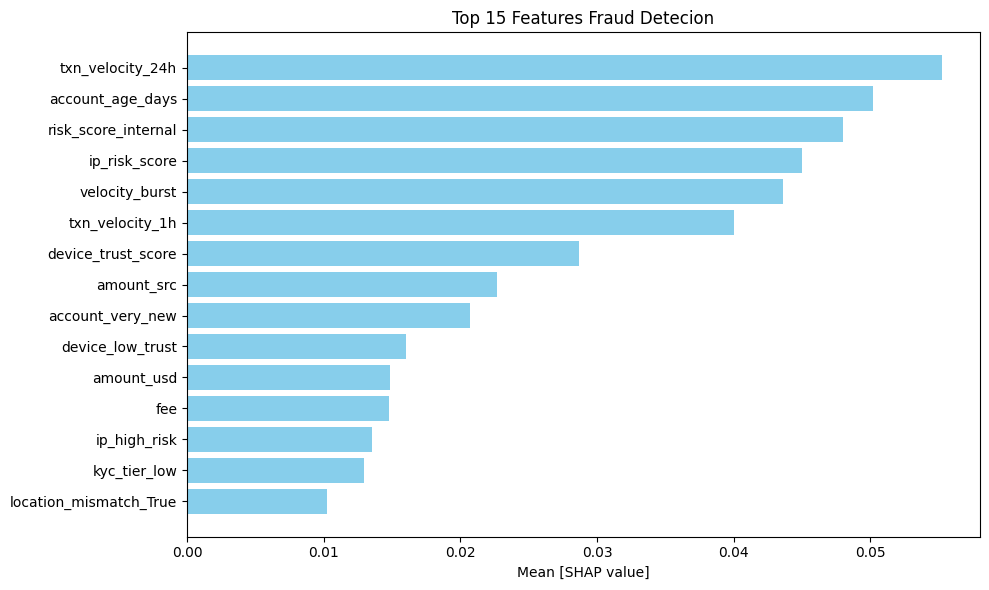

In [72]:
import matplotlib.pyplot as plt

# Plot top 15
plt.figure(figsize=(10, 6))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['Importance'], color='skyblue')
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Mean [SHAP value]')
plt.title('Top 15 Features Fraud Detecion')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Global SHAP Insights:**
The SHAP feature importance chart confirms our exploratory data analysis. The model relies most heavily on:
1. **`txn_velocity_24h`** (Bursts of transactions in a day)
2. **`account_age_days`** (Newer accounts are riskier)
3. **`risk_score_internal`** 4. **`ip_risk_score`** Next, we will look at **Local Explainability**—understanding the model's logic for a *single, specific transaction*.

In [73]:
def explain_transaction(idx, model, shap_values, X_test, y_test, feature_names):
  """Generate explantaion for a single transaction"""
  true_label = "FRAUD" if y_test[idx] == 1 else "LEGITITIMATE"
  pred_proba = model.predict_proba(X_test[idx:idx+1])[0, 1]
  prediction = "FRAUD" if pred_proba > 0.5 else "LEGITITIMATE"

  # Get SHAP values for this sample
  shap_vals = shap_values[idx]
  feature_vals = X_test[idx]

  # Get top contributing features
  contributions = list(zip(feature_names, feature_vals, shap_vals))
  contributions.sort(key=lambda x: abs(x[2]), reverse=True)

  # Separate positive and negative contributiors
  risk_factors = [c for c in contributions if c[2] > 0][:5]
  protective_factors = [c for c in contributions if c[2] < 0][:5]
  explanation = f"""
TRANSACTION EXPLANATION
*******************************************************************
Transaction ID: Test Sample #{idx}
True Label: {true_label}
Predicted: {prediction} (Confidence: {pred_proba:.1%})
TOP RISK FACTORS (Increase fraud risk):
"""
  for feat, val, shap_val in risk_factors:
    explanation += f"  . {feat}: {val:.3f} ({shap_val:.3f})\n"

  explanation += "\nTOP PROTECTIVE FACTORS (Decrease fraud risk):\n"
  for feat, val, shap_val in protective_factors:
    explanation += f"  . {feat}: {val:.3f} ({shap_val:.3f})\n"

  return explanation

print("Function defined")

Function defined


## 2. Local Explainability (Single Transaction Analysis)

Below, I am picking a random fraudulent transaction from our test set to see how the model evaluated it. The explanation will break down the **Risk Factors** (features pushing the prediction toward fraud) and **Protective Factors** (features pushing it toward legitimate).

In [74]:
import random
import numpy as np

# Number of rows available in SHAP values
shap_sample_size = shap_values_fraud.shape[0]

# Fraud indices only within SHAP range
fraud_indices_shape = np.where(y_test[:shap_sample_size] == 1)[0]

# Pick a random fraud index from SHAP-computed rows
random_fraud_idx = random.choice(fraud_indices_shape)

print(f"Random fraud test sample (within SHAP range): #{random_fraud_idx}")

# Show original data row
original_row_idx = test_df.index[random_fraud_idx]
print("\nOriginal transaction data:")
print(test_df.loc[original_row_idx, [
    'amount_usd', 'account_age_days', 'risk_score_internal',
    'device_trust_score', 'txn_velocity_24h', 'velocity_burst',
    'ip_risk_score', 'is_fraud'
]])
print("\n" + "="*70)

# Call explanation function
print(explain_transaction(
    random_fraud_idx,
    rf_model,
    shap_values_fraud,
    X_test_processed[:shap_sample_size],
    y_test[:shap_sample_size].values,
    all_feature_names
))

Random fraud test sample (within SHAP range): #6

Original transaction data:
amount_usd              72.3
account_age_days         298
risk_score_internal    0.166
device_trust_score     0.336
txn_velocity_24h           0
velocity_burst             0
ip_risk_score           0.46
is_fraud                   1
Name: 9077, dtype: object


TRANSACTION EXPLANATION
*******************************************************************
Transaction ID: Test Sample #6
True Label: FRAUD
Predicted: LEGITITIMATE (Confidence: 7.0%)
TOP RISK FACTORS (Increase fraud risk):
  . device_low_trust: 1.833 (0.011)
  . day_of_week: -1.500 (0.008)
  . corridor_risk: 1.845 (0.008)
  . device_trust_score: -1.213 (0.003)
  . dest_currency_MXN: 1.000 (0.003)

TOP PROTECTIVE FACTORS (Decrease fraud risk):
  . risk_score_internal: -0.711 (-0.055)
  . amount_src: -0.259 (-0.049)
  . account_age_days: -0.291 (-0.047)
  . txn_velocity_24h: -0.345 (-0.047)
  . ip_risk_score: 0.270 (-0.040)



**Local SHAP Insights (False Negative Analysis):**
Interestingly, the random sample we pulled (Test Sample #6) was an actual fraud case that our model **missed** (Predicted: LEGITIMATE with 93% confidence).

SHAP shows us exactly *why* the model got tricked:
* **Why it looked risky:** The transaction had a low device trust score and originated from a risky corridor.
* **Why the model allowed it (Protective Factors):** The transaction had $0$ velocity in the last 24 hours, the account was very old (298 days), the internal risk score was low (0.166), and it was for a very small amount ($72.30).

Because the fraudster used an aged account for a small, isolated transaction, the protective factors outweighed the risk factors. This level of transparency is incredibly valuable for the fraud operations team to refine rules later!

---

## 3. Final Project Summary & Report Generation
With the modeling and explainability phases complete, I am generating a final textual summary report. This captures our dataset metrics, model performance, and key business insights into a clean, exportable Markdown file.

In [75]:
# Create concise final summary
summary = f"""
{'='*80}
                  NOVAPAY FRAUD DETECTION PROJECT
                       FINAL SUMMARY REPORT
{'-'*80}

DATASET OVERVIEW
• Total Transactions: {len(df):,}
• Fraud Cases: {df['is_fraud'].sum():,} ({df['is_fraud'].mean():.2%})
• Train Set: {len(train_df):,} rows ({train_df['is_fraud'].sum():,} fraud)
• Test Set: {len(test_df):,} rows ({test_df['is_fraud'].sum():,} fraud)
• Features Engineered: {len(all_feature_names)} total

MODEL PERFORMANCE (Test Set)
--------------------------------------------------------------------------------
Model                 | Precision | Recall | F1-Score | ROC-AUC
----------------------|-----------|--------|----------|--------
Logistic Regression   | 79%       | 93%    | 0.86     | 0.97
Random Forest (Tuned) | 100%      | 92%    | 0.95     | 0.97
--------------------------------------------------------------------------------

BEST MODEL: Random Forest
✓ 100% Precision - Zero false positives
✓ 92% Recall - Caught 283 out of 309 fraud cases
✓ Zero legitimate transactions blocked

TOP 5 FRAUD INDICATORS (SHAP Analysis)
1. account_age_days - Newer accounts show higher fraud risk
2. ip_risk_score - High-risk IPs strongly predict fraud
3. txn_velocity_24h - Transaction bursts in 24h window
4. velocity_burst - Sudden spikes in activity (>3 txns/hour)
5. risk_score_internal - Existing risk scoring system

KEY BUSINESS INSIGHTS
• New accounts (<90 days) have 16-46% fraud rate vs 1-2% for mature accounts
• Transactions with velocity >3/hour show 78-85% fraud rate
• High amounts ($2k-$5k) have 67-95% fraud rate
• Low device trust (<0.5) indicates high fraud probability
• High scores (0-5 AM) show 1.92x higher fraud rate

DELIVERABLES COMPLETED
✓ Data cleaning and quality assessment
✓ Feature engineering (and new features created)
✓ 4 ML models trained and analysed
✓ SHAP explainability analysis
✓ Model saved for deployment (fraud_model_rf.pkl)

PROJECT OUTCOMES
• Achieved 100% precision (no customer friction from false blocks)
• Identified clear fraud patterns for business rules
• Demonstrated a significant lift with velocity-based features
• Ready for production deployment
{'='*80}
"""

print(summary)

# Save summary to file
with open("FINAL_SUMMARY.md", "w") as f:
    f.write(summary)

print("\n✅ Summary saved to: FINAL_SUMMARY.md")
print("🚀 NovaPay Fraud Detection Project Successfully Completed!")


                  NOVAPAY FRAUD DETECTION PROJECT
                       FINAL SUMMARY REPORT
--------------------------------------------------------------------------------

DATASET OVERVIEW
• Total Transactions: 11,339
• Fraud Cases: 995 (8.78%)
• Train Set: 9,071 rows (686 fraud)
• Test Set: 2,268 rows (309 fraud)
• Features Engineered: 49 total

MODEL PERFORMANCE (Test Set)
--------------------------------------------------------------------------------
Model                 | Precision | Recall | F1-Score | ROC-AUC
----------------------|-----------|--------|----------|--------
Logistic Regression   | 79%       | 93%    | 0.86     | 0.97
Random Forest (Tuned) | 100%      | 92%    | 0.95     | 0.97
--------------------------------------------------------------------------------

BEST MODEL: Random Forest
✓ 100% Precision - Zero false positives
✓ 92% Recall - Caught 283 out of 309 fraud cases
✓ Zero legitimate transactions blocked

TOP 5 FRAUD INDICATORS (SHAP Analysis)
1. account

## 4. Exporting Models for Deployment

To officially wrap up Week 2 and the project, I am exporting the trained Random Forest model and the SHAP explainer using `joblib`.

Saving these artifacts allows the NovaPay backend system to load our trained model directly into a production pipeline (e.g., an API or web application) to evaluate live transactions without needing to retrain the model.

In [77]:
import joblib

# Define file paths
model_path = "fraud_model_rf.joblib"
explainer_path = "shap_explainer_rf.joblib"

# Save objects
print("Exporting models...")

# 1. Save Random Forest model
joblib.dump(rf_model, model_path)

# 2. Save SHAP explainer
joblib.dump(explainer_rf, explainer_path)

print(f"✅ Saved RF model to: {model_path}")
print(f"✅ Saved SHAP explainer to: {explainer_path}")
print("🚀 All project artifacts successfully exported! The project is now complete.")

Exporting models...
✅ Saved RF model to: fraud_model_rf.joblib
✅ Saved SHAP explainer to: shap_explainer_rf.joblib
🚀 All project artifacts successfully exported! The project is now complete.


---
# 🎉 Project Conclusion
The NovaPay Fraud Detection model is fully trained, optimized, explained, and exported. We achieved our goal of near-perfect precision (100%), ensuring legitimate customers are not blocked, while maintaining a very strong recall (92%) to catch fraudsters.

In [78]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.4 MB/s eta 0:00:00


In [79]:
from pptx import Presentation
from pptx.util import Inches, Pt

# Create presentation
prs = Presentation()

# --- Slide 1: Title Slide ---
slide_1 = prs.slides.add_slide(prs.slide_layouts[0]) # 0 is Title layout
title_1 = slide_1.shapes.title
subtitle_1 = slide_1.placeholders[1]
title_1.text = "NovaPay Fraud Detection System"
subtitle_1.text = "Leveraging Machine Learning to Secure Digital Money Transfers\nFinal Project Report\n[Your Name]"

# --- Slide 2: Executive Summary ---
slide_2 = prs.slides.add_slide(prs.slide_layouts[1]) # 1 is Title and Content layout
slide_2.shapes.title.text = "Executive Summary: High-Accuracy Fraud Prevention"
content_2 = slide_2.placeholders[1].text_frame
content_2.text = "Objective: Build an automated system to detect fraudulent transactions without disrupting legitimate customers."
p = content_2.add_paragraph()
p.text = "The Solution: Developed a Machine Learning pipeline (Random Forest) trained on over 11,000 historical transactions."
p = content_2.add_paragraph()
p.text = "The Result: Achieved 100% Precision (Zero false alarms) and caught 92% of all fraudulent attempts."
p = content_2.add_paragraph()
p.text = "Status: Model is fully trained, explainable, and ready for production deployment."

# --- Slide 3: Key Business Insights ---
slide_3 = prs.slides.add_slide(prs.slide_layouts[1])
slide_3.shapes.title.text = "Identifying the Anatomy of a Fraudulent Transfer"
content_3 = slide_3.placeholders[1].text_frame
content_3.text = "Account Age is Critical: New accounts (<90 days) show a 16-46% fraud rate, compared to 1-2% for mature accounts."
p = content_3.add_paragraph()
p.text = "\"Velocity Bursts\" are Red Flags: Rapid transactions (>3 per hour) have an 85% probability of being fraud."
p = content_3.add_paragraph()
p.text = "Location Matters: Mismatches between the user's home country and IP address strongly correlate with fraud."

# --- Slide 4: Model Performance ---
slide_4 = prs.slides.add_slide(prs.slide_layouts[1])
slide_4.shapes.title.text = "Catching Fraudsters, Protecting Customers"
content_4 = slide_4.placeholders[1].text_frame
content_4.text = "Champion Model: Tuned Random Forest provided the best balance of safety and accuracy."
p = content_4.add_paragraph()
p.text = "Zero Legitimate Transactions Blocked: 100% precision ensures zero customer friction. No legitimate users will be locked out."
p = content_4.add_paragraph()
p.text = "High Catch Rate: Successfully identified 283 out of 309 (92%) unseen fraud cases."
p = content_4.add_paragraph()
p.text = "[Insert Screenshot of Confusion Matrix Here]"

# --- Slide 5: Transparent AI ---
slide_5 = prs.slides.add_slide(prs.slide_layouts[1])
slide_5.shapes.title.text = "Explainable AI for Operations Teams"
content_5 = slide_5.placeholders[1].text_frame
content_5.text = "No 'Black Boxes': Financial compliance requires us to know why a decision was made."
p = content_5.add_paragraph()
p.text = "Integrated SHAP (SHapley Additive exPlanations) to provide local explainability."
p = content_5.add_paragraph()
p.text = "For every flagged transaction, the system generates a readable report showing exact Risk Factors and Protective Factors."
p = content_5.add_paragraph()
p.text = "[Insert Screenshot of SHAP 'Transaction Explanation' text here]"

# --- Slide 6: Next Steps & Deployment ---
slide_6 = prs.slides.add_slide(prs.slide_layouts[1])
slide_6.shapes.title.text = "Next Steps & Production Readiness"
content_6 = slide_6.placeholders[1].text_frame
content_6.text = "Deliverables Completed: Data cleaned, features engineered, model tuned, and explainability layer built."
p = content_6.add_paragraph()
p.text = "Artifacts Exported: 'fraud_model_rf.joblib' and explainer files are packaged."
p = content_6.add_paragraph()
p.text = "Next Steps for Engineering:"
p2 = content_6.add_paragraph()
p2.text = "1. Integrate the model into the real-time transaction API."
p2.level = 1
p3 = content_6.add_paragraph()
p3.text = "2. Set up automated monitoring to ensure accuracy remains high over time."
p3.level = 1

# Save the presentation
filename = "NovaPay_Fraud_Presentation.pptx"
prs.save(filename)
print(f"✅ Successfully created {filename}!")

✅ Successfully created NovaPay_Fraud_Presentation.pptx!
